**Proyecto Analisis de Datos Python**
**VENTAS MOTOS**
*Jose Alejandro Martinez Juarez*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:

df = pd.read_csv("Ventas_Motos.csv")

print(list(df.columns))
print(f"Filas    : {df.shape[0]}")
print(f"Columnas : {df.shape[1]}")
print(df.head())


['Id_Venta', 'Nombre', 'Apellido', 'Edad', 'Sexo', 'Ciudad', 'Marca', 'Modelo', 'Tipo_Moto', 'Cilindraje_cc', 'Color', 'Año_Fabricacion', 'Kilometraje', 'Precio_Lista', 'Descuento_Pct', 'Precio_Final', 'Forma_Pago', 'Sucursal', 'Vendedor', 'Uso_Moto', 'Accesorios', 'Estado_Venta', 'Satisfaccion_1_5', 'Año_Venta', 'Mes_Venta']
Filas    : 1515
Columnas : 25
   Id_Venta     Nombre   Apellido  Edad       Sexo   Ciudad          Marca  \
0         1       Juan   Martinez  56.0  Masculino   Puebla            BMW   
1         2      Elena     Moreno  56.0   Femenino     Leon  Royal Enfield   
2         3        Ana  Rodriguez  53.0   Femenino   Puebla  Royal Enfield   
3         4    Daniela    Jimenez  61.0   Femenino   Puebla         Suzuki   
4         5  Francisco    Morales  29.0  Masculino  Tijuana          Honda   

        Modelo  Tipo_Moto  Cilindraje_cc  ... Precio_Final        Forma_Pago  \
0       F750GS      Naked            250  ...      5441.88           Leasing   
1    Himalaya

In [9]:

print("INFORMACION GENERAL")
print(df.info())

print("\nESTADISTICAS GENERALES")
print(df.describe())


INFORMACION GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1515 entries, 0 to 1514
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id_Venta          1515 non-null   int64  
 1   Nombre            1515 non-null   object 
 2   Apellido          1515 non-null   object 
 3   Edad              1475 non-null   float64
 4   Sexo              1515 non-null   object 
 5   Ciudad            1515 non-null   object 
 6   Marca             1515 non-null   object 
 7   Modelo            1515 non-null   object 
 8   Tipo_Moto         1515 non-null   object 
 9   Cilindraje_cc     1515 non-null   int64  
 10  Color             1515 non-null   object 
 11  Año_Fabricacion   1515 non-null   int64  
 12  Kilometraje       1475 non-null   float64
 13  Precio_Lista      1515 non-null   float64
 14  Descuento_Pct     1515 non-null   int64  
 15  Precio_Final      1515 non-null   float64
 16  Forma_Pago        1515

In [10]:
#Valores nulos por columna
print("====VALORES NULOS POR COLUMNA====")
nulos = df.isnull().sum()
print(nulos[nulos > 0])
print(f"\nTotal nulos en todo el dataset: {df.isnull().sum().sum()}")

#Duplicados
print(f"\n=== DUPLICADOS ===")
print(f"Registros duplicados encontrados: {df.duplicated().sum()}")

#Outliers visibles (edades imposibles)
print(f"\n=== OUTLIERS DE EDAD ===")
print(df[df["Edad"] > 100][["Nombre", "Apellido", "Edad"]])

#Precios en cero (datos incorrectos)
print(f"\n=== PRECIOS EN CERO ===")
print(f"Ventas con precio = 0: {(df['Precio_Final'] == 0).sum()}")


====VALORES NULOS POR COLUMNA====
Edad                40
Kilometraje         40
Satisfaccion_1_5    40
dtype: int64

Total nulos en todo el dataset: 120

=== DUPLICADOS ===
Registros duplicados encontrados: 15

=== OUTLIERS DE EDAD ===
        Nombre Apellido   Edad
316      Paula  Ramirez  200.0
560  Valentina     Cruz  200.0
597    Daniela  Jimenez  200.0
767      Elena   Moreno  200.0
885      Laura   Torres  200.0

=== PRECIOS EN CERO ===
Ventas con precio = 0: 10


In [11]:
print("====LIMPIEZA DE DATOS====")
print(f"Registros ANTES de limpiar : {len(df)}")

#1.-Eliminar duplicados
df.drop_duplicates(inplace=True)
print(f"Despues de eliminar duplicados : {len(df)}")

#2.-Corregir outliers de Edad (edad > 100 no es real)
df.loc[df["Edad"] > 100, "Edad"] = np.nan
print(f"Outliers de Edad corregidos a NaN")

#3.-Rellenar nulos de Edad con la mediana
mediana_edad = df["Edad"].median()
df["Edad"].fillna(mediana_edad, inplace=True)
print(f"Edad: nulos rellenados con mediana = {mediana_edad:.0f} anos")

#4.-Rellenar nulos de Kilometraje con 0 (moto nueva sin km)
df["Kilometraje"].fillna(0, inplace=True)
print(f"Kilometraje: nulos rellenados con 0")

#5.-Rellenar nulos de Satisfaccion con la mediana
mediana_sat = df["Satisfaccion_1_5"].median()
df["Satisfaccion_1_5"].fillna(mediana_sat, inplace=True)
print(f"Satisfaccion: nulos rellenados con mediana = {mediana_sat:.0f}")

#6.-Eliminar filas con Precio_Final = 0 (dato incorrecto)
df = df[df["Precio_Final"] > 0]
print(f"Filas con precio = 0 eliminadas")


print(f"\nRegistros DESPUES de limpiar : {len(df)}")
print(f"Nulos restantes              : {df.isnull().sum().sum()}")


====LIMPIEZA DE DATOS====
Registros ANTES de limpiar : 1515
Despues de eliminar duplicados : 1500
Outliers de Edad corregidos a NaN
Edad: nulos rellenados con mediana = 42 anos
Kilometraje: nulos rellenados con 0
Satisfaccion: nulos rellenados con mediana = 4
Filas con precio = 0 eliminadas

Registros DESPUES de limpiar : 1490
Nulos restantes              : 0


C:\Users\gzq43v\AppData\Local\Temp\ipykernel_40584\3333510727.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Edad"].fillna(mediana_edad, inplace=True)
C:\Users\gzq43v\AppData\Local\Temp\ipykernel_40584\3333510727.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

In [16]:
print("=" * 50)
print("=KPIs - VENTAS DE MOTOS - JOSE ALEJANDRO MARTINEZ=")
print("=" * 50)

#Total de ventas
total_ventas = len(df[df["Estado_Venta"] == "Vendida"])
print(f"\nTotal ventas concretadas    : {total_ventas:,}")

# Ingresos totales y promedio
ingreso_total = df[df["Estado_Venta"] == "Vendida"]["Precio_Final"].sum()
ingreso_prom  = df[df["Estado_Venta"] == "Vendida"]["Precio_Final"].mean()
print(f"Ingreso total               : ${ingreso_total:,.2f}")
print(f"Precio promedio por moto    : ${ingreso_prom:,.2f}")

# Moto mas vendida
Moto_masvendida = df[df["Estado_Venta"] == "Vendida"]["Marca"].value_counts().idxmax()
Moto_Qt_Masvendida  = df[df["Estado_Venta"] == "Vendida"]["Marca"].value_counts().max()
print(f"\nMarca mas vendida           : {Moto_masvendida} ({Moto_Qt_Masvendida} unidades)")

#Sucursal con mas ventas
suc_masventas = df[df["Estado_Venta"] == "Vendida"]["Sucursal"].value_counts().idxmax()
print(f"Sucursal mas exitosa        : {suc_masventas}")

# Forma de pago mas usada
pago_tmasusado = df["Forma_Pago"].value_counts().idxmax()
print(f"Forma de pago preferida     : {pago_tmasusado}")

#Satisfaccion promedio
sat_prom = df["Satisfaccion_1_5"].mean()
print(f"Satisfaccion promedio       : {sat_prom:.2f} / 5.0")

#Crecimiento por año
print(f"\n--- Ventas por Año ---")
ventas_año = df[df["Estado_Venta"]=="Vendida"].groupby("Año_Venta")["Precio_Final"].sum()
for año, total in ventas_año.items():
    print(f"   {año}: ${total:,.2f}")

print("\n" + "=" * 50)


=KPIs - VENTAS DE MOTOS - JOSE ALEJANDRO MARTINEZ=

Total ventas concretadas    : 1,098
Ingreso total               : $16,385,648.71
Precio promedio por moto    : $14,923.18

Marca mas vendida           : Yamaha (157 unidades)
Sucursal mas exitosa        : Queretaro
Forma de pago preferida     : Contado
Satisfaccion promedio       : 3.84 / 5.0

--- Ventas por Año ---
   2022: $2,550,912.67
   2023: $3,571,101.77
   2024: $6,456,606.03
   2025: $3,807,028.24



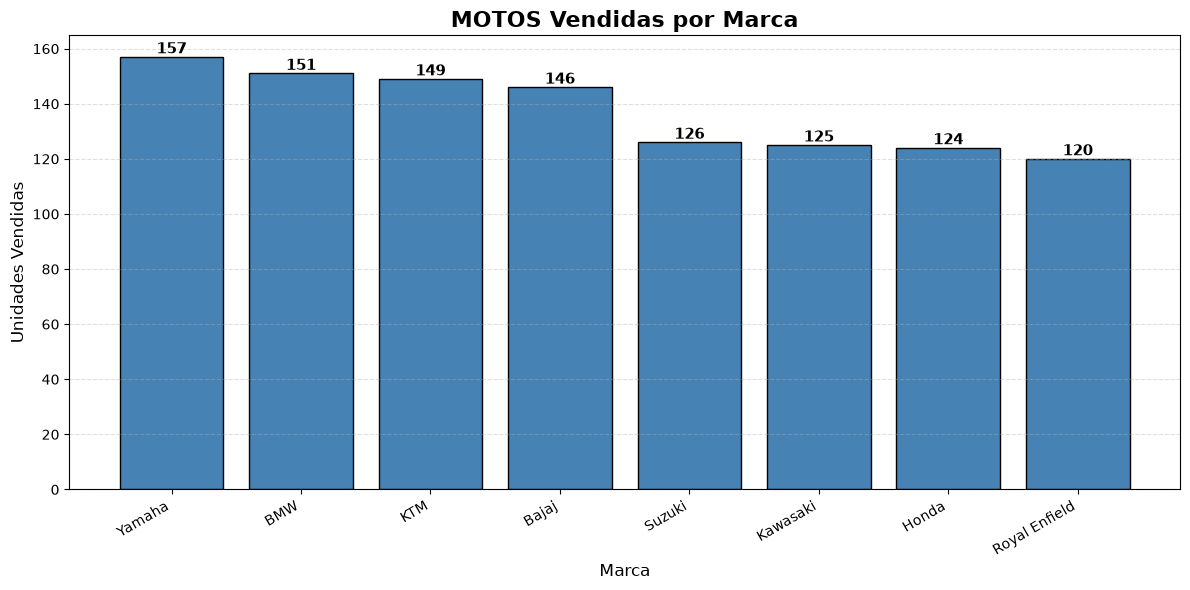

In [ ]:
# GRAFICA 1-Barras: ventas por marca de moto
plt.figure(figsize=(12, 6))

ventas_marca = df[df["Estado_Venta"] == "Vendida"]["Marca"].value_counts()

bars = plt.bar(ventas_marca.index, ventas_marca.values, color="steelblue", edgecolor="black")



plt.title("MOTOS Vendidas por Marca", fontsize=16, fontweight="bold")
plt.xlabel("Marca", fontsize=12)
plt.ylabel("Unidades Vendidas", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.grid(True, linestyle="--", alpha=0.4, axis="y")
plt.bar_label(bars, fontweight="bold", fontsize=11)
plt.tight_layout()
plt.show()


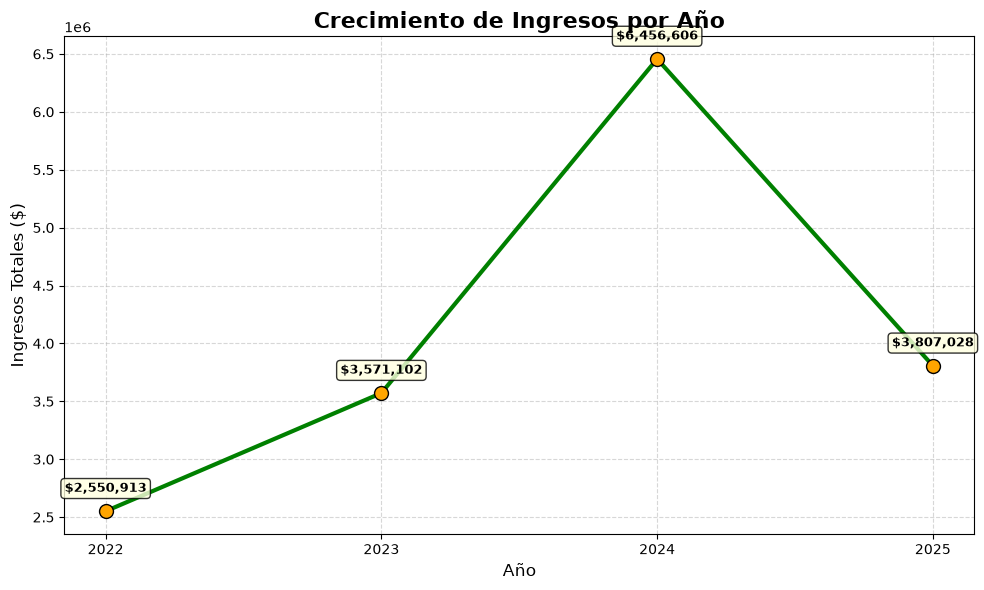

In [ ]:
# GRAFICA 2-Linea: crecimiento de ingresos por año
plt.figure(figsize=(10, 6))

ingresos_año = df[df["Estado_Venta"]=="Vendida"].groupby("Año_Venta")["Precio_Final"].sum()

plt.plot(ingresos_año.index, ingresos_año.values,color="green", marker="o", linestyle="-",linewidth=3, markersize=10, markerfacecolor="orange", markeredgecolor="black")


for año, ingreso in ingresos_año.items():
    plt.annotate(f"${ingreso:,.0f}",
                 (año, ingreso),
                 textcoords="offset points",
                 xytext=(0, 14),
                 ha="center", fontsize=9, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.3",
                           facecolor="lightyellow", alpha=0.8))

plt.title("Crecimiento de Ingresos por Año", fontsize=16, fontweight="bold")
plt.xlabel("Año", fontsize=12)
plt.ylabel("Ingresos Totales ($)", fontsize=12)
plt.xticks([2022, 2023, 2024, 2025])
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


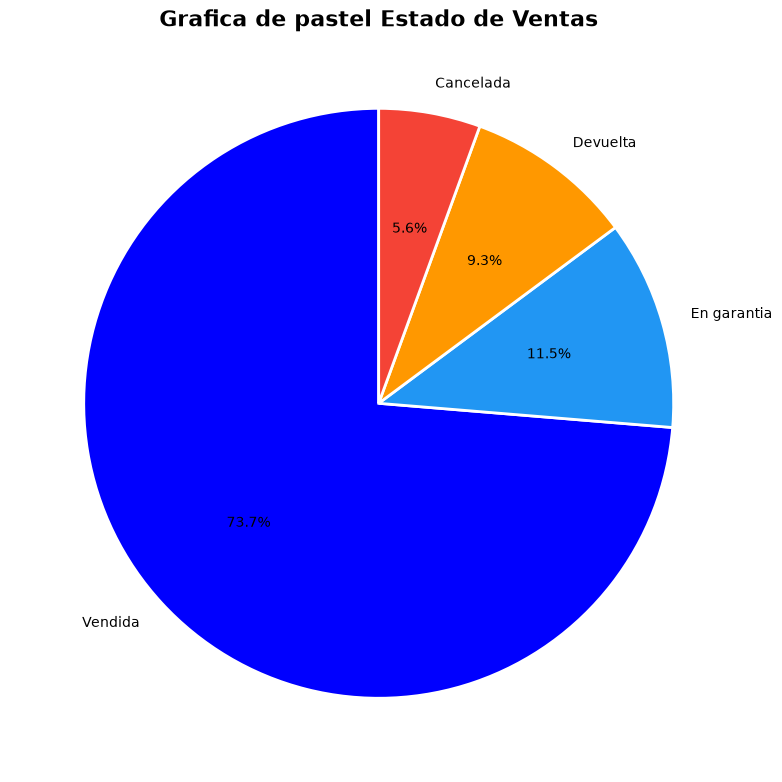

In [ ]:
# GRAFICA 3-Pay: distribucion del estado de ventas
plt.figure(figsize=(8, 8))

estado_counts = df["Estado_Venta"].value_counts()
colores = ["#4CAF50", "#2196F3", "#FF9800", "#F44336"]

plt.pie(estado_counts.values,labels=estado_counts.index,colors= colores,autopct="%1.1f%%",startangle= 90,wedgeprops= dict(edgecolor="white", linewidth=2))

plt.title("Grafica de pastel Estado de Ventas",fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
print("=" * 50)
print("  CONCLUSIONES - Proyecto Motos - Jose Alejandro Martinez")
print("=" * 50)
print(f"""
1. El dataset contenia 1,515 registros con datos sucios:
   120 valores nulos, 15 duplicados, 5 outliers de edad
   y 10 precios en cero. Todos fueron corregidos.

2. Se concretaron {total_ventas} ventas con un ingreso total
   de ${ingreso_total:,.0f} pesos.

3. La marca mas vendida fue {Moto_masvendida} con {Moto_Qt_Masvendida} unidades
   y la sucursal con mejor desempeno fue {suc_masventas}.

4. La forma de pago preferida es {pago_tmasusado}, lo que
   indica que los clientes prefieren financiamiento.

5. La satisfaccion promedio fue {sat_prom:.2f}/5.0, reflejando
   una buena experiencia de compra en general.

6. La grafica de linea fue la mas util para identificar
   el crecimiento de ingresos año con año de forma clara.
""")
print("=" * 50)


  CONCLUSIONES - Proyecto Motos - Jose Alejandro Martinez

1. El dataset contenia 1,515 registros con datos sucios:
   120 valores nulos, 15 duplicados, 5 outliers de edad
   y 10 precios en cero. Todos fueron corregidos.

2. Se concretaron 1098 ventas con un ingreso total
   de $16,385,649 pesos.

3. La marca mas vendida fue Yamaha con 157 unidades
   y la sucursal con mejor desempeno fue Queretaro.

4. La forma de pago preferida es Contado, lo que
   indica que los clientes prefieren financiamiento.

5. La satisfaccion promedio fue 3.84/5.0, reflejando
   una buena experiencia de compra en general.

6. La grafica de linea fue la mas util para identificar
   el crecimiento de ingresos año con año de forma clara.

